# 臉部偵測(Face Detection)

## 載入相關套件

In [ ]:
# 載入相關套件，包含OpenCV-Python
import cv2
import matplotlib.pyplot as plt
from cv2 import imread, rectangle

## 載入級聯分類器(face cascade file)

In [2]:
# 載入臉部級聯分類器(face cascade file)
face_cascade = 'cascade_files/haarcascade_frontalface_alt.xml'
classifier = cv2.CascadeClassifier(face_cascade)

## 載入圖檔

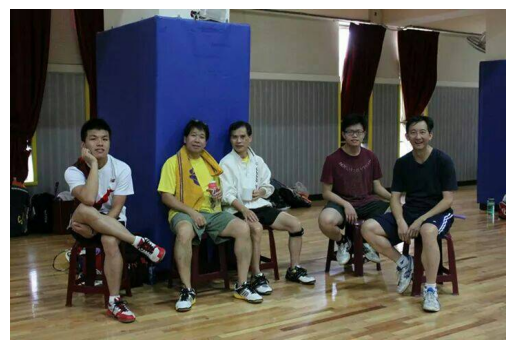

In [ ]:
# 載入測試圖檔
image_file = "images_face/teammates.jpg"
image = imread(image_file)
if image is None:
    raise FileNotFoundError(image_file)

# OpenCV 預設為 BGR 色系，轉為 RGB 色系
im_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 顯示圖像
plt.imshow(im_rgb)
plt.axis('off')
plt.show()

## 偵測臉部並顯示圖像

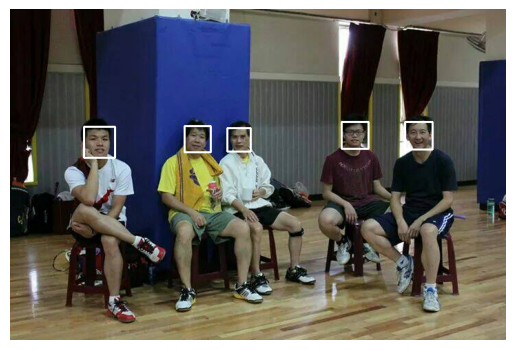

In [ ]:
if image is None:
    raise FileNotFoundError(image_file)

# 偵測臉部
bboxes = classifier.detectMultiScale(image)
# 臉部加框
for box in bboxes:
    # 取得框的座標及寬高
    x, y, width, height = box
    x2, y2 = x + width, y + height
    # 加白色框
    rectangle(im_rgb, (x, y), (x2, y2), (255, 255, 255), 2)

# 顯示圖像
plt.imshow(im_rgb)
plt.axis('off')
plt.show()

## 載入另一圖檔

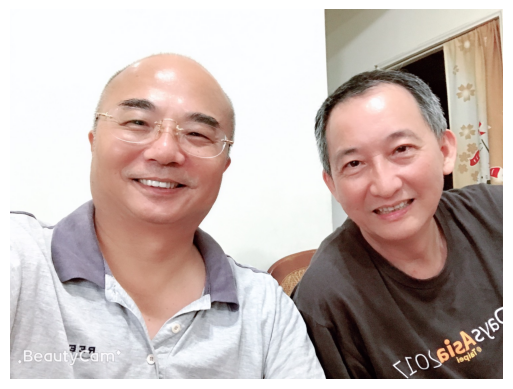

In [5]:
# 載入圖檔
image_file = "images_face/classmates.jpg"
image = imread(image_file)
if image is None:
    raise FileNotFoundError(image_file)

# OpenCV 預設為 BGR 色系，轉為 RGB 色系
im_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 顯示圖像
plt.imshow(im_rgb)
plt.axis('off')
plt.show()

## 偵測臉部並顯示圖像

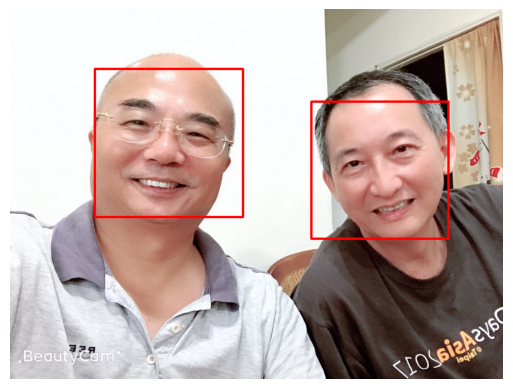

In [ ]:
if image is None:
    raise FileNotFoundError(image_file)

# 偵測臉部
bboxes = classifier.detectMultiScale(image)
# 臉部加框
for box in bboxes:
    # 取得框的座標及寬高
    x, y, width, height = box
    x2, y2 = x + width, y + height
    # 加紅色框
    rectangle(im_rgb, (x, y), (x2, y2), (255, 0, 0), 5)

# 顯示圖像
plt.imshow(im_rgb)
plt.axis('off')
plt.show()

## 載入眼睛及微笑級聯分類器

In [7]:
# 載入眼睛級聯分類器(eye cascade file)
eye_cascade = 'cascade_files/haarcascade_eye_tree_eyeglasses.xml'
eye_classifier = cv2.CascadeClassifier(eye_cascade)

# 載入微笑級聯分類器(smile cascade file)
smile_cascade = 'cascade_files/haarcascade_smile.xml'
smile_classifier = cv2.CascadeClassifier(smile_cascade)

## 偵測臉部並顯示圖像

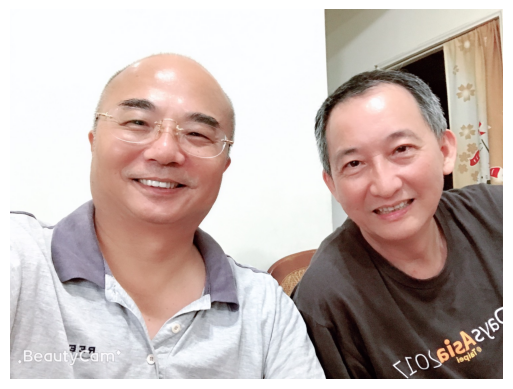

In [ ]:
if image is None:
    raise FileNotFoundError(image_file)
# OpenCV 預設為 BGR 色系，轉為 RGB 色系
im_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 顯示圖像
plt.imshow(im_rgb)
plt.axis('off')
plt.show()

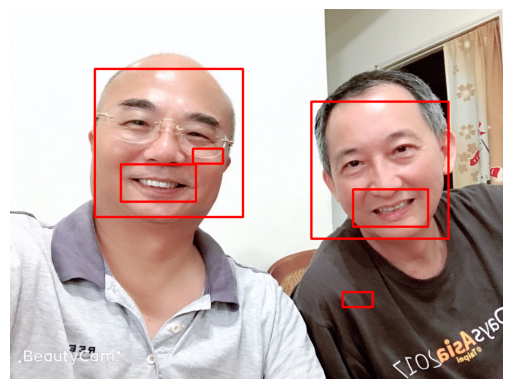

In [ ]:
if image is None:
    raise FileNotFoundError(image_file)

im_rgb_clone = im_rgb.copy()
# 偵測臉部
bboxes = classifier.detectMultiScale(image)
# 臉部加框
for box in bboxes:
    # 取得框的座標及寬高
    x, y, width, height = box
    x2, y2 = x + width, y + height
    # 加白色框
    rectangle(im_rgb_clone, (x, y), (x2, y2), (255, 0, 0), 5)

# 偵測微笑
# scaleFactor=2.5：掃描時每次縮減掃描視窗的尺寸比例。
# minNeighbors=20：每一個被選中的視窗至少要有鄰近且合格的視窗數
bboxes = smile_classifier.detectMultiScale(image, 2.5, 20)
# 微笑加框
for box in bboxes:
    # 取得框的座標及寬高
    x, y, width, height = box
    x2, y2 = x + width, y + height
    # 加白色框
    rectangle(im_rgb_clone, (x, y), (x2, y2), (255, 0, 0), 5)
#     break

# 顯示圖像
plt.imshow(im_rgb_clone)
plt.axis('off')
plt.show()

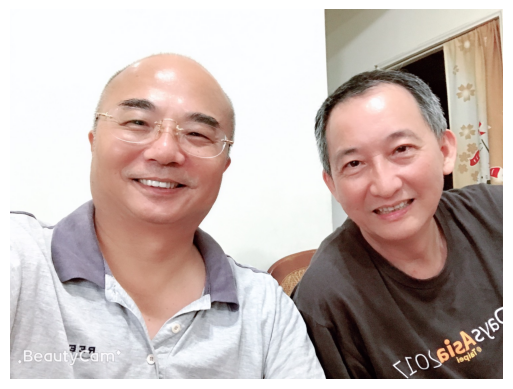

In [ ]:
if image is None:
    raise FileNotFoundError(image_file)
# OpenCV 預設為 BGR 色系，轉為 RGB 色系
im_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 顯示圖像
plt.imshow(im_rgb)
plt.axis('off')
plt.show()

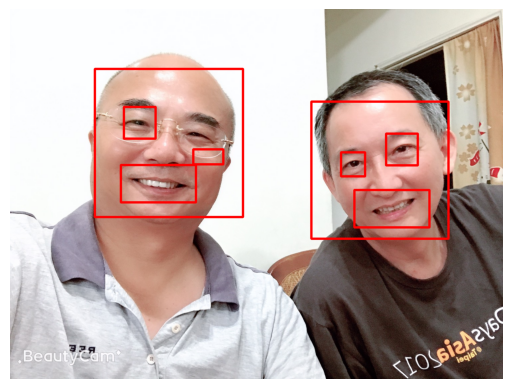

In [ ]:
if image is None:
    raise FileNotFoundError(image_file)

im_rgb_clone = im_rgb.copy()
# 偵測臉部
bboxes = classifier.detectMultiScale(image)
# 臉部加框
for box in bboxes:
    # 取得框的座標及寬高
    x, y, width, height = box
    x2, y2 = x + width, y + height
    # 加白色框
    rectangle(im_rgb_clone, (x, y), (x2, y2), (255, 0, 0), 5)

    # 偵測眼睛
    face_box = image[y:y2, x:x2]
    bboxes_eye = eye_classifier.detectMultiScale(face_box, 1.1, 5)
    # 加框
    for box_eye in bboxes_eye:
        # 取得框的座標及寬高
        x, y, width, height = box_eye
        x2, y2 = x + width, y + height
        # 加白色框
        rectangle(im_rgb_clone, (x + box[0], y + box[1]), (x2 + box[0], y2 + box[1]), (255, 0, 0), 5)

    # 偵測微笑
    # scaleFactor=2.5：掃描時每次縮減掃描視窗的尺寸比例。
    # minNeighbors=20：每一個被選中的視窗至少要有鄰近且合格的視窗數
    bboxes_smile = smile_classifier.detectMultiScale(face_box, 2.5, 20, 0)
    # 加框
    for box_smile in bboxes_smile:
        # 取得框的座標及寬高
        x, y, width, height = box_smile
        x2, y2 = x + width, y + height
        # 加白色框
        rectangle(im_rgb_clone, (x + box[0], y + box[1]), (x2 + box[0], y2 + box[1]), (255, 0, 0), 5)

# 顯示圖像
plt.imshow(im_rgb_clone)
plt.axis('off')
plt.show()